# Football Market Value Prediction
**TDDE64 Sports Analytics — Linköping University**

## Project overview

The goal is to predict Premier League players' market values using only on-field performance statistics, then benchmark those predictions against Transfermarkt's crowd-sourced values and actual transfer fees.

This follows the methodology of *"Data-Driven Models for Predicting Field Player Market Value in European Football"* (IEEE doc 11264761), which reports R² > 0.80 using Random Forest and XGBoost across European leagues.

### Pipeline
```
API-Football (stats) ──┐
                       ├── join.py ── features.py ── models.py
Transfermarkt (values) ┘
```

### Data sources
- **API-Football**: per-match aggregated stats (goals, assists, passes, tackles, etc.) for all PL players, queried by team to work around the free-tier page limit
- **Transfermarkt**: historical market valuations (target variable), club metadata, and actual transfer fees (for benchmarking)

### Important modeling choices
- **Exclude goalkeepers** — their value drivers are completely different from field players
- **Log-transform the target**: `y = log1p(market_value_eur)` — market values are heavily right-skewed
- **Temporal train/test split**: train on past seasons, test on the most recent (no data leakage)
- **Position-aware models**: separate DEF / MID / FWD models, compared against a single global model

In [1]:
import logging
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

logging.basicConfig(level=logging.INFO, format='%(levelname)s %(message)s')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 120

---
## 1. Load data

We have two independent data sources that need to be loaded and filtered to Premier League players before they can be joined.

### 1a. Transfermarkt
`load_transfermarkt()` reads four CSVs from `data/raw/transfermarkt/` and filters each to PL-relevant rows:
- **clubs**: all clubs with `domestic_competition_id == 'GB1'` (Premier League competition code)
- **valuations**: all historical market value snapshots recorded while a player was at a PL club — this is our **target variable**
- **players**: all players who appear in the PL valuations (i.e. anyone who has ever played in the PL, not just current squad members)
- **transfers**: all transfers where at least one club is a PL club — used later for benchmarking predictions against real fees

### 1b. API-Football
`fetch_api_football()` queries the cached JSON files in `data/raw/api_football/`. On first run it hits the network; on subsequent runs it reads from disk, so the 100 req/day limit is only consumed once.

We query by **team** (not by league) to avoid the free-tier page-3 cap on the league endpoint. Each team's squad fits in 1–3 pages, and we have 22 PL team IDs across the 3 seasons.

In [2]:
from src.ingest import load_transfermarkt, fetch_api_football

tm = load_transfermarkt()
api_players = fetch_api_football(seasons=[2022, 2023, 2024])

print(f"Transfermarkt — clubs: {len(tm.clubs)}  players: {len(tm.players)}  "
      f"valuations: {len(tm.valuations)}  transfers: {len(tm.transfers)}")
print(f"API-Football  — player-records: {len(api_players)}")

INFO PL clubs: 37
INFO PL valuations rows: 32726
INFO PL players: 2854
INFO PL transfers: 8724
INFO   [1/22] team 33 — 40 players (PL), 40 total so far
INFO   [2/22] team 34 — 37 players (PL), 77 total so far
INFO   [3/22] team 35 — 47 players (PL), 124 total so far
INFO   [4/22] team 36 — 44 players (PL), 168 total so far
INFO   [5/22] team 39 — 45 players (PL), 213 total so far
INFO   [6/22] team 40 — 43 players (PL), 256 total so far
INFO   [7/22] team 41 — 43 players (PL), 299 total so far
INFO   [8/22] team 42 — 40 players (PL), 339 total so far
INFO   [9/22] team 45 — 44 players (PL), 383 total so far
INFO   [10/22] team 46 — 38 players (PL), 421 total so far
INFO   [11/22] team 47 — 48 players (PL), 469 total so far
INFO   [12/22] team 48 — 47 players (PL), 516 total so far
INFO   [13/22] team 49 — 40 players (PL), 556 total so far
INFO   [14/22] team 50 — 29 players (PL), 585 total so far
INFO   [15/22] team 51 — 44 players (PL), 629 total so far
INFO   [16/22] team 52 — 42 pla

Transfermarkt — clubs: 37  players: 2854  valuations: 32726  transfers: 8724
API-Football  — player-records: 2898


---
## 2. Join

API-Football and Transfermarkt use completely different internal player IDs, so we match them manually using player identity attributes.

### Matching strategy (three-step cascade)

1. **Exact match on full name + date of birth** — the most reliable signal. Both names are normalized first: accents stripped via `unidecode`, lowercased, punctuation removed. This catches most mainstream players.

2. **Exact match on last name + date of birth** — handles cases where API-Football stores a compound last name (e.g. *"Danjuma Adam Groeneveld"*) that Transfermarkt splits differently. DOB acts as a hard disambiguator so last-name collisions are rare.

3. **Fuzzy match on full name, same DOB** — uses `rapidfuzz.token_sort_ratio` (threshold ≥ 80) to catch spelling differences and name ordering variations. DOB must still match exactly, limiting false positives.

Players with no match are dropped — they have no market value to predict against.

### Expected match rate
Target is 80–90% per the project plan. Many unmatched players are fringe squad / academy players who appear in the API but have never had a Transfermarkt valuation recorded.

In [3]:
from src.join import build_crosswalk, build_joined_dataset

crosswalk = build_crosswalk(api_players, tm.players)

print("Match method breakdown:")
print(crosswalk['match_method'].value_counts().to_string())
print(f"\nOverall match rate: {crosswalk['tm_player_id'].notna().mean():.1%}")

INFO Match rate: 974/1430 (68.1%)
INFO   exact_full=269  exact_last=479  fuzzy=226  unmatched=456


Match method breakdown:
match_method
exact_last    479
unmatched     456
exact_full    269
fuzzy         226

Overall match rate: 68.1%


### Attaching market values

For each matched player-season, we snap the Transfermarkt valuation to the **closest date to July 1 of season end** (e.g. July 1 2023 for the 2022/23 season). This gives us the market value at the point when the season's stats are complete.

Players who transferred mid-season appear multiple times in the API data (one row per club). We **sum their stats** across all clubs before computing features — a player who scored 5 goals at club A and 3 at club B contributed 8 goals to that season.

In [4]:
joined = build_joined_dataset(api_players, tm)
print(f"Joined dataset: {len(joined)} rows (player-season-club entries)")
print(f"Unique player-seasons: {joined.drop_duplicates(['api_player_id','season']).shape[0]}")
print(f"Unique players: {joined['api_player_id'].nunique()}")
joined.head(3)

INFO Match rate: 974/1430 (68.1%)
INFO   exact_full=269  exact_last=479  fuzzy=226  unmatched=456
INFO Joined dataset: 6407 player-season-club rows, 1780 unique player-seasons


Joined dataset: 6407 rows (player-season-club entries)
Unique player-seasons: 1780
Unique players: 865


,api_player_id,season,firstname,lastname,dob,nationality,position,team_name,team_id,appearances,...,duels_total,duels_won,dribbles_attempts,dribbles_success,fouls_drawn,fouls_committed,full_name_norm,last_name_norm,tm_player_id,market_value_in_eur
0,889,2022,Victor Jörgen,Nilsson Lindelöf,1994-07-17,Sweden,Defender,Manchester United,33,20.0,...,102.0,61.0,3.0,2.0,4.0,10.0,victor jorgen nilsson lindelof,nilsson lindelof,184573.0,18000000.0
1,889,2022,Victor Jörgen,Nilsson Lindelöf,1994-07-17,Sweden,Defender,Manchester United,33,4.0,...,14.0,6.0,NaN,NaN,NaN,1.0,victor jorgen nilsson lindelof,nilsson lindelof,184573.0,18000000.0
2,889,2022,Victor Jörgen,Nilsson Lindelöf,1994-07-17,Sweden,Defender,Manchester United,33,6.0,...,16.0,11.0,NaN,NaN,1.0,1.0,victor jorgen nilsson lindelof,nilsson lindelof,184573.0,18000000.0


---
## 3. Exploratory Data Analysis

Before building models, we need to understand the distribution of the target variable and the relationships between features. This section answers three key questions:

1. Is the market value distribution skewed, and does log-transformation fix it?
2. Do different positions have systematically different value distributions?
3. Which performance features correlate most strongly with market value?

In [5]:
from src.features import build_stage1, _aggregate_multi_club, _add_age, _normalize_position

s1 = build_stage1(joined)
print(f"Stage 1 dataset: {len(s1)} player-seasons, {s1.shape[1]} columns")

INFO Stage 1: 1691 player-seasons, 10 features


Stage 1 dataset: 1691 player-seasons, 15 columns


### 3a. Market value distribution

Football market values are well-known to follow a heavy right tail — a handful of elite players (Haaland, Salah, etc.) are worth 10–20× the median. This violates the normality assumption of linear regression and makes RMSE misleading in raw EUR.

The fix is `log1p(market_value_eur)`, which compresses the tail and makes the distribution roughly normal. All models train on this log-transformed target. We report metrics in both log-space (R², RMSE_log) and back-transformed EUR (MAE_eur) for interpretability.

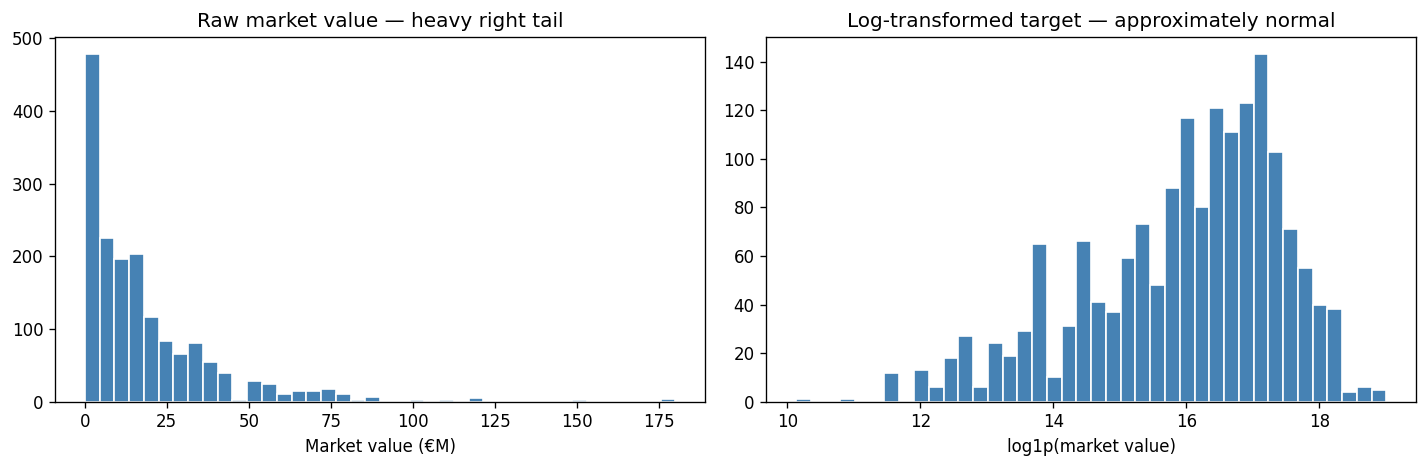

Raw:  mean=€18.6M  median=€12.0M  max=€180M


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(s1['market_value_in_eur'] / 1e6, bins=40, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Market value (€M)')
axes[0].set_title('Raw market value — heavy right tail')

axes[1].hist(s1['log_market_value'], bins=40, color='steelblue', edgecolor='white')
axes[1].set_xlabel('log1p(market value)')
axes[1].set_title('Log-transformed target — approximately normal')

plt.tight_layout()
plt.show()

print(f"Raw:  mean=€{s1['market_value_in_eur'].mean()/1e6:.1f}M  median=€{s1['market_value_in_eur'].median()/1e6:.1f}M  max=€{s1['market_value_in_eur'].max()/1e6:.0f}M")

### 3b. Market value by position

Forwards tend to command higher market values than defenders and midfielders — goals are the most visible contribution and easier for scouts to quantify. This position-specific value difference is one reason the reference paper trains **separate models per position** rather than a single global model.

If we pooled all positions, the model would need to simultaneously learn that "10 goals" means something very different for a striker vs. a centre-back. Separate models let each position's features speak to its own value drivers.

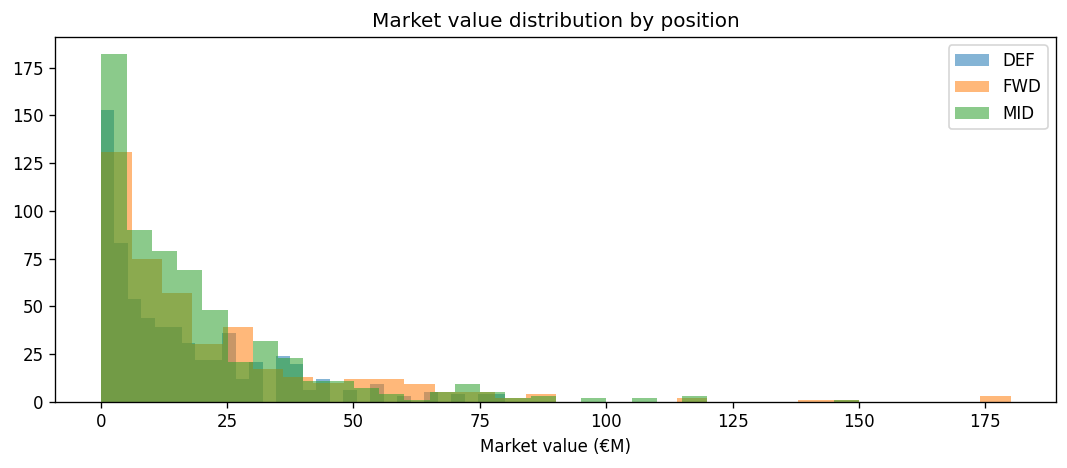

,median,mean,max
position,,,
DEF,€10.0M,€15.9M,€80.0M
FWD,€13.0M,€21.8M,€180.0M
MID,€13.0M,€19.1M,€150.0M


In [7]:
s1_pos = s1.copy()
s1_pos['position'] = s1[[c for c in s1.columns if c.startswith('pos_')]].idxmax(axis=1).str.replace('pos_', '')

fig, ax = plt.subplots(figsize=(9, 4))
for pos, grp in s1_pos.groupby('position'):
    ax.hist(grp['market_value_in_eur'] / 1e6, bins=30, alpha=0.55, label=pos)
ax.set_xlabel('Market value (€M)')
ax.set_title('Market value distribution by position')
ax.legend()
plt.tight_layout()
plt.show()

s1_pos.groupby('position')['market_value_in_eur'].agg(['median','mean','max']).map(lambda x: f'€{x/1e6:.1f}M')

### 3c. Age curve

Market value follows an **inverted U-shape with age** — players peak in their mid-to-late 20s and decline steeply after 30. This reflects both current performance and future sell-on value.

In Stage 3 features we add `age²` to let linear models capture this curvature. Tree models (RF, XGBoost) can learn it automatically through splits.

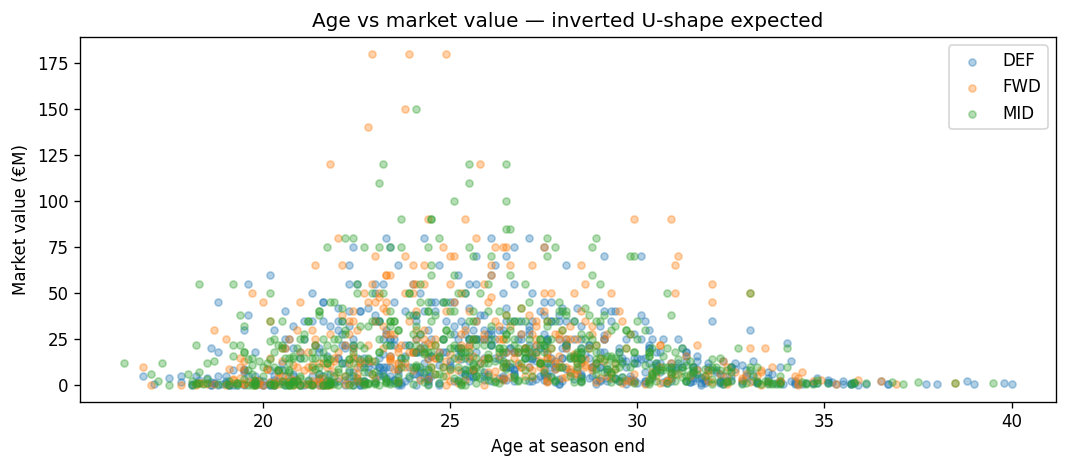

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
for pos, grp in s1_pos.groupby('position'):
    ax.scatter(grp['age'], grp['market_value_in_eur'] / 1e6, alpha=0.35, s=18, label=pos)
ax.set_xlabel('Age at season end')
ax.set_ylabel('Market value (€M)')
ax.set_title('Age vs market value — inverted U-shape expected')
ax.legend()
plt.tight_layout()
plt.show()

### 3d. Feature correlations

A Pearson correlation heatmap gives a quick read of which Stage 1 features are most linearly associated with `log_market_value`. Minutes and appearances are expected to correlate strongly with value — players worth more get more game time. Goals and assists should also be positive.

Age is expected to have a weak or near-zero linear correlation because the relationship is non-linear (inverted U).

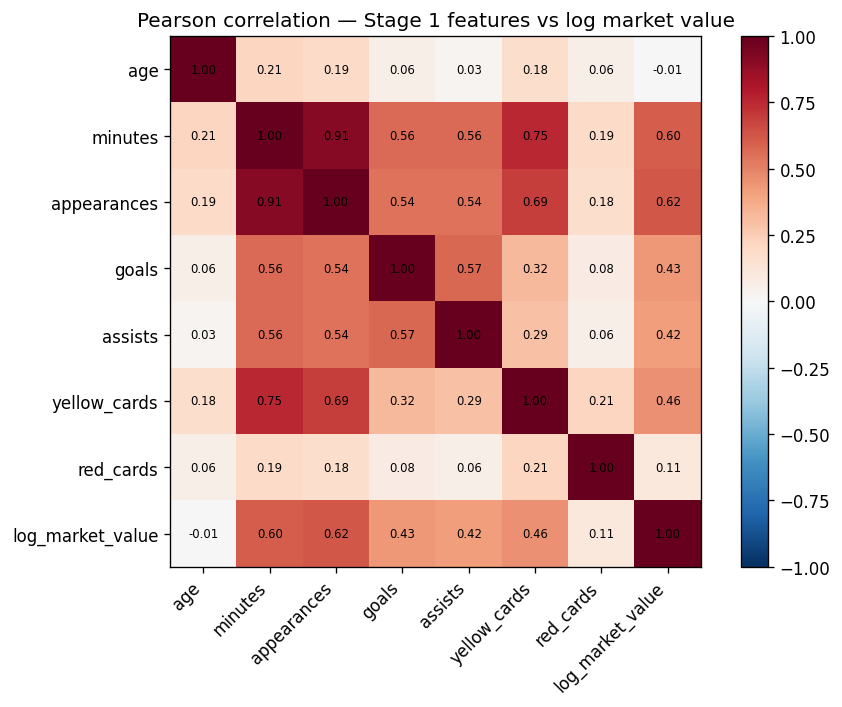

In [9]:
feat_cols = ['age', 'minutes', 'appearances', 'goals', 'assists',
             'yellow_cards', 'red_cards', 'log_market_value']
corr = s1[feat_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(feat_cols)))
ax.set_yticks(range(len(feat_cols)))
ax.set_xticklabels(feat_cols, rotation=45, ha='right')
ax.set_yticklabels(feat_cols)
for i in range(len(feat_cols)):
    for j in range(len(feat_cols)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)
ax.set_title('Pearson correlation — Stage 1 features vs log market value')
plt.tight_layout()
plt.show()

### 3e. Top 10 most valuable players

A sanity check — the highest-valued players in our dataset should be recognisable names. If we see obvious errors here (e.g. unknown reserve players at the top), it suggests a join error or valuation date mismatch.

In [10]:
agg = _normalize_position(_add_age(_aggregate_multi_club(joined)))
top10 = (agg.nlargest(10, 'market_value_in_eur')
           [['firstname', 'lastname', 'position_group', 'age', 'goals', 'assists', 'minutes', 'market_value_in_eur']]
           .assign(market_value_in_eur=lambda d: d['market_value_in_eur'].apply(lambda x: f'€{x/1e6:.0f}M'))
           .reset_index(drop=True))
top10

,firstname,lastname,position_group,age,goals,assists,minutes,market_value_in_eur
0,Erling,Braut Haaland,FWD,22.9,54.0,9.0,4066.0,€180M
1,Erling,Braut Haaland,FWD,23.9,38.0,6.0,3842.0,€180M
2,Erling,Braut Haaland,FWD,24.9,31.0,3.0,3664.0,€180M
3,Philip Walter,Foden,MID,24.1,27.0,12.0,4377.0,€150M
4,Bukayo Ayoyinka Temidayo,Saka,FWD,23.8,18.0,15.0,3380.0,€150M
5,Bukayo Ayoyinka Temidayo,Saka,FWD,22.8,22.0,12.0,4110.0,€140M
6,Bukayo Ayoyinka Temidayo,Saka,FWD,21.8,18.0,11.0,3898.0,€120M
7,Alexander,Isak,FWD,25.8,27.0,6.0,3319.0,€120M
8,Declan,Rice,MID,25.5,7.0,17.0,4339.0,€120M
9,Declan,Rice,MID,26.5,13.0,12.0,5132.0,€120M


---
## 4. Feature engineering

We mirror the three-stage experimental design from the reference paper. Running all models at each stage lets us isolate the marginal contribution of each feature group.

### Stage 1 — Basic (~10 features)
Age, one-hot position (DEF / MID / FWD), minutes played, appearances, goals, assists, yellow cards, red cards.
These are the simplest objective stats — anything a casual fan would know about a player.

### Stage 2 — Expanded (~22 features)
Stage 1 plus **per-90-minute versions** of all counting stats (goals/90, assists/90, passes/90, etc.) and rate stats (pass accuracy, dribble success %, duels won %, shot accuracy).
Per-90 stats normalise for playing time — a player who scores 10 goals in 900 minutes is equivalent to one who scores 5 in 450. This is the standard in modern football analytics.

> **Note on linear models in Stage 2**: per-90 stats can be extreme for players with very few minutes (1 goal in 45 mins = 2.0 goals/90). With 100+ correlated features for small position subsets, unregularised linear regression completely breaks down. This is visible in the Stage 2 results and is an interesting finding to discuss in the report.

### Stage 3 — Domain-informed (~30+ features)
Stage 2 plus `age²` (captures the non-linear age curve), position-relative percentile ranks (is this player's goal rate in the top 25% for their position?), and — once multiple seasons are loaded — **Δ-stats** (year-over-year change in goals, assists, minutes) which signal trajectory.

In [11]:
from src.features import build_stage1, build_stage2, build_stage3

s1 = build_stage1(joined)
s2 = build_stage2(joined)
s3 = build_stage3(joined)

for name, df in [('Stage 1', s1), ('Stage 2', s2), ('Stage 3', s3)]:
    feat_cols = [c for c in df.columns if c not in
                 {'api_player_id','season','tm_player_id','market_value_in_eur','log_market_value'}]
    print(f"{name}: {len(df)} player-seasons, {len(feat_cols)} features")
    print(f"  Features: {feat_cols}\n")

INFO Stage 1: 1691 player-seasons, 10 features
INFO Stage 2: 1691 player-seasons, 22 features
INFO Stage 2: 1691 player-seasons, 22 features
INFO Stage 3: 1691 player-seasons, 34 columns


Stage 1: 1691 player-seasons, 10 features
  Features: ['age', 'minutes', 'appearances', 'goals', 'assists', 'yellow_cards', 'red_cards', 'pos_DEF', 'pos_FWD', 'pos_MID']

Stage 2: 1691 player-seasons, 22 features
  Features: ['age', 'minutes', 'appearances', 'goals_p90', 'assists_p90', 'shots_total_p90', 'shots_on_p90', 'passes_total_p90', 'passes_key_p90', 'tackles_p90', 'interceptions_p90', 'dribbles_attempts_p90', 'dribbles_success_p90', 'fouls_drawn_p90', 'fouls_committed_p90', 'passes_accuracy', 'duels_won_pct', 'shot_accuracy', 'dribble_success_pct', 'pos_DEF', 'pos_FWD', 'pos_MID']

Stage 3: 1691 player-seasons, 29 features
  Features: ['age', 'minutes', 'appearances', 'goals_p90', 'assists_p90', 'shots_total_p90', 'shots_on_p90', 'passes_total_p90', 'passes_key_p90', 'tackles_p90', 'interceptions_p90', 'dribbles_attempts_p90', 'dribbles_success_p90', 'fouls_drawn_p90', 'fouls_committed_p90', 'passes_accuracy', 'duels_won_pct', 'shot_accuracy', 'dribble_success_pct', 'pos_DEF', 

---
## 5. Models

### Models used

| Model | Role | Notes |
|---|---|---|
| **Linear Regression** | Baseline | No regularisation — expected to overfit on Stage 2/3 |
| **Ridge Regression** | Regularised baseline | L2 penalty (α=10) stabilises correlated per-90 features |
| **Random Forest** | Main model | 200 trees, handles non-linearity and feature interactions well |
| **XGBoost** | Main model | Gradient boosting — typically best single model in tabular tasks |

### Evaluation protocol

**Temporal train/test split**: train on 2022/23 + 2023/24, test on 2024/25. This is the correct evaluation for time-series data — random splits would leak future information into the training set. The test set is a true held-out season the model has never seen.

### Metrics
- **R²**: proportion of variance explained — the headline number, target is > 0.80 (paper benchmark)
- **RMSE_log / MAE_log**: error in log-transformed space — model-comparable
- **MAE_eur**: mean absolute error back-transformed to euros — human-interpretable ("off by €X million on average")
- **Spearman ρ**: rank correlation — measures whether the model correctly orders players by value, even if absolute predictions are off

In [12]:
from src.models import train_global, train_position_aware, results_to_df

all_results = []
for stage_name, df in [('stage1', s1), ('stage2', s2), ('stage3', s3)]:
    print(f'\n--- {stage_name} ---')
    all_results += train_global(df, stage_name)
    all_results += train_position_aware(df, stage_name)

table = results_to_df(all_results)
table

INFO   [global] LinearRegression  R²=0.380  RMSE_log=1.066  MAE_eur=€13M
INFO   [global] Ridge  R²=0.381  RMSE_log=1.065  MAE_eur=€13M



--- stage1 ---


INFO   [global] RandomForest  R²=0.493  RMSE_log=0.964  MAE_eur=€8M
INFO   [global] XGBoost  R²=0.497  RMSE_log=0.960  MAE_eur=€8M
INFO   [DEF] LinearRegression  R²=0.369  RMSE_log=1.064  MAE_eur=€13M
INFO   [DEF] Ridge  R²=0.376  RMSE_log=1.058  MAE_eur=€13M
INFO   [DEF] RandomForest  R²=0.514  RMSE_log=0.935  MAE_eur=€8M
INFO   [DEF] XGBoost  R²=0.496  RMSE_log=0.951  MAE_eur=€8M
INFO   [MID] LinearRegression  R²=0.397  RMSE_log=1.071  MAE_eur=€12M
INFO   [MID] Ridge  R²=0.401  RMSE_log=1.067  MAE_eur=€11M
INFO   [MID] RandomForest  R²=0.382  RMSE_log=1.084  MAE_eur=€8M
INFO   [MID] XGBoost  R²=0.350  RMSE_log=1.112  MAE_eur=€9M
INFO   [FWD] LinearRegression  R²=0.357  RMSE_log=1.061  MAE_eur=€15M
INFO   [FWD] Ridge  R²=0.359  RMSE_log=1.059  MAE_eur=€15M
INFO   [FWD] RandomForest  R²=0.531  RMSE_log=0.906  MAE_eur=€9M
INFO   [FWD] XGBoost  R²=0.436  RMSE_log=0.994  MAE_eur=€10M
INFO   [global] LinearRegression  R²=0.310  RMSE_log=1.125  MAE_eur=€40M
INFO   [global] Ridge  R²=0.311  


--- stage2 ---


INFO   [global] RandomForest  R²=0.499  RMSE_log=0.958  MAE_eur=€8M
INFO   [global] XGBoost  R²=0.495  RMSE_log=0.963  MAE_eur=€8M
INFO   [DEF] LinearRegression  R²=0.390  RMSE_log=1.046  MAE_eur=€11M
INFO   [DEF] Ridge  R²=0.394  RMSE_log=1.043  MAE_eur=€11M
INFO   [DEF] RandomForest  R²=0.515  RMSE_log=0.933  MAE_eur=€7M
INFO   [DEF] XGBoost  R²=0.526  RMSE_log=0.922  MAE_eur=€7M
INFO   [MID] LinearRegression  R²=0.363  RMSE_log=1.101  MAE_eur=€10M
INFO   [MID] Ridge  R²=0.405  RMSE_log=1.064  MAE_eur=€10M
INFO   [MID] RandomForest  R²=0.427  RMSE_log=1.043  MAE_eur=€9M
INFO   [MID] XGBoost  R²=0.401  RMSE_log=1.067  MAE_eur=€9M
INFO   [FWD] LinearRegression  R²=-0.451  RMSE_log=1.593  MAE_eur=€4292M
INFO   [FWD] Ridge  R²=-0.301  RMSE_log=1.509  MAE_eur=€2772M
INFO   [FWD] RandomForest  R²=0.531  RMSE_log=0.906  MAE_eur=€9M
INFO   [FWD] XGBoost  R²=0.418  RMSE_log=1.009  MAE_eur=€9M
INFO   [global] LinearRegression  R²=0.543  RMSE_log=0.915  MAE_eur=€9M
INFO   [global] Ridge  R²=0.5


--- stage3 ---


INFO   [global] RandomForest  R²=0.571  RMSE_log=0.887  MAE_eur=€8M
INFO   [global] XGBoost  R²=0.596  RMSE_log=0.860  MAE_eur=€7M
INFO   [DEF] LinearRegression  R²=0.523  RMSE_log=0.925  MAE_eur=€8M
INFO   [DEF] Ridge  R²=0.547  RMSE_log=0.902  MAE_eur=€8M
INFO   [DEF] RandomForest  R²=0.580  RMSE_log=0.869  MAE_eur=€7M
INFO   [DEF] XGBoost  R²=0.598  RMSE_log=0.850  MAE_eur=€7M
INFO   [MID] LinearRegression  R²=0.481  RMSE_log=0.993  MAE_eur=€9M
INFO   [MID] Ridge  R²=0.441  RMSE_log=1.031  MAE_eur=€10M
INFO   [MID] RandomForest  R²=0.490  RMSE_log=0.985  MAE_eur=€8M
INFO   [MID] XGBoost  R²=0.449  RMSE_log=1.024  MAE_eur=€8M
INFO   [FWD] LinearRegression  R²=0.201  RMSE_log=1.182  MAE_eur=€41M
INFO   [FWD] Ridge  R²=0.140  RMSE_log=1.226  MAE_eur=€66M
INFO   [FWD] RandomForest  R²=0.580  RMSE_log=0.857  MAE_eur=€9M
INFO   [FWD] XGBoost  R²=0.507  RMSE_log=0.929  MAE_eur=€9M


,stage,position,model,n,R²,RMSE_log,MAE_log,Spearman_ρ,MAE_eur_M
0,stage1,global,LinearRegression,561,0.380,1.066,0.827,0.702,13.2
1,stage1,global,Ridge,561,0.381,1.065,0.827,0.702,13.2
2,stage1,global,RandomForest,561,0.493,0.964,0.684,0.807,8.4
3,stage1,global,XGBoost,561,0.497,0.960,0.677,0.805,8.3
4,stage1,DEF,LinearRegression,224,0.369,1.064,0.837,0.681,13.5
5,stage1,DEF,Ridge,224,0.376,1.058,0.832,0.685,13.3
6,stage1,DEF,RandomForest,224,0.514,0.935,0.684,0.796,7.5
7,stage1,DEF,XGBoost,224,0.496,0.951,0.700,0.789,7.7
8,stage1,MID,LinearRegression,188,0.397,1.071,0.802,0.714,11.7
9,stage1,MID,Ridge,188,0.401,1.067,0.800,0.714,11.5


### 5a. R² by feature stage — global model

This is the main results chart. Each group of bars is one feature stage; the four bars within each group are the four models. The red dashed line marks the R²=0.80 benchmark from the reference paper.

**What to expect:** Tree models (RF, XGBoost) should improve or stay flat as we add more features. Linear models may degrade at Stage 2 due to correlated per-90 stats. The gap between tree models and linear models widens as feature complexity increases — evidence that the value function is non-linear.

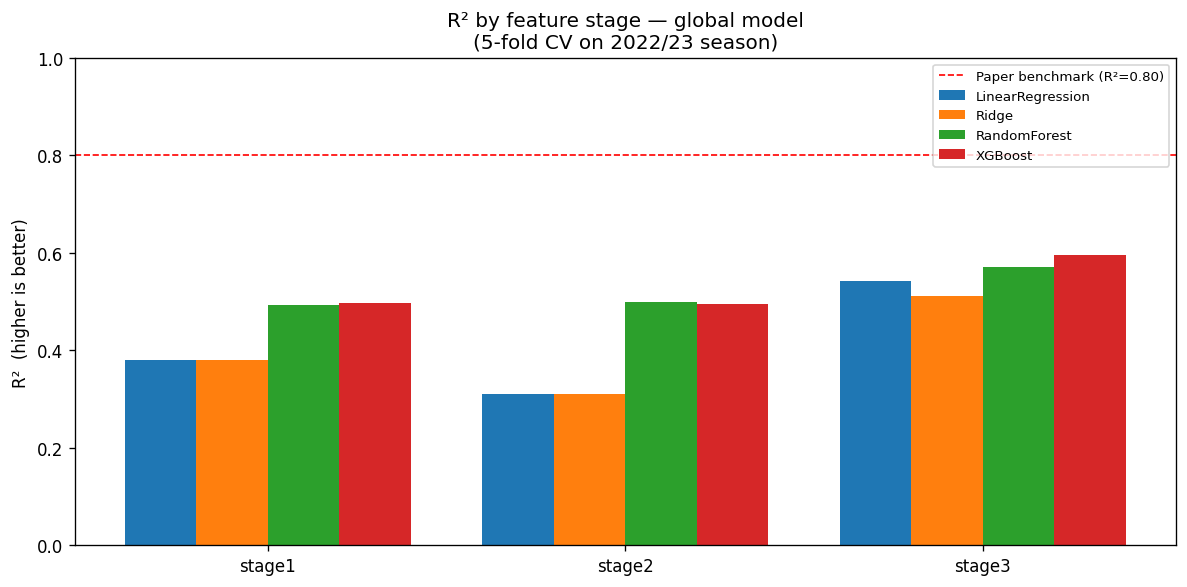

In [13]:
global_df = table[table['position'] == 'global'].copy()
stages = global_df['stage'].unique()
models = global_df['model'].unique()

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(stages))
width = 0.2

for i, model in enumerate(models):
    sub = global_df[global_df['model'] == model]
    r2_vals = [sub[sub['stage'] == s]['R²'].values[0] if len(sub[sub['stage'] == s]) else 0 for s in stages]
    ax.bar(x + i * width, r2_vals, width, label=model)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(stages)
ax.set_ylabel('R²  (higher is better)')
ax.set_title('R² by feature stage — global model\n(5-fold CV on 2022/23 season)')
ax.axhline(0.8, color='red', linestyle='--', linewidth=1.0, label='Paper benchmark (R²=0.80)')
ax.legend(fontsize=8)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### 5b. Position-aware vs global — Random Forest, Stage 1

One of our research questions is whether training **separate models per position** (DEF / MID / FWD) outperforms a single global model. The reference paper finds it does.

The global model (blue) sees all positions together. The position-specific models (orange) each see only their position group. If the orange bars are higher, position-aware training is adding value — each model learns the specific value drivers for that position without being confused by the different scales of other positions.

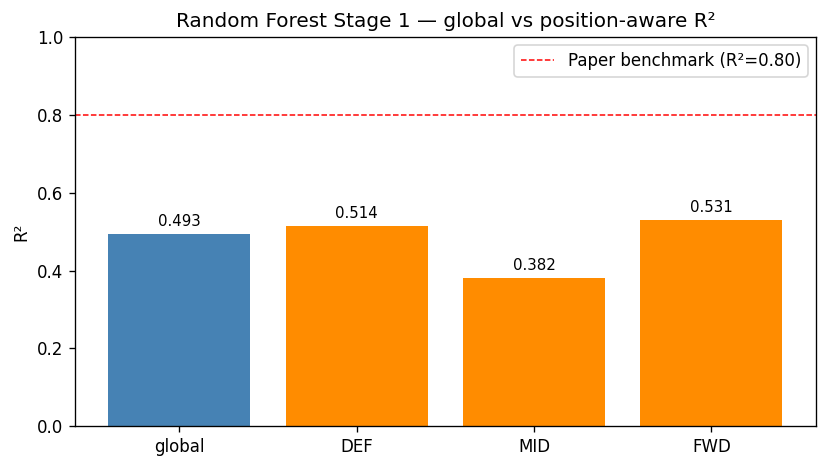

In [14]:
rf_s1 = table[(table['model'] == 'RandomForest') & (table['stage'] == 'stage1')].copy()

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['steelblue' if p == 'global' else 'darkorange' for p in rf_s1['position']]
bars = ax.bar(rf_s1['position'], rf_s1['R²'], color=colors)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.axhline(0.8, color='red', linestyle='--', linewidth=0.9, label='Paper benchmark (R²=0.80)')
ax.set_ylabel('R²')
ax.set_title('Random Forest Stage 1 — global vs position-aware R²')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### 5c. Mean Absolute Error in EUR

R² tells us how much variance the model explains, but MAE in euros is what matters practically: "on average, our prediction is off by €X million."

For context, a MAE of €7M on a dataset with a median value of €12M means we're within one order of magnitude for most players, but will be more wrong on extreme values (star players worth €100M+). This is expected — extreme values are the hardest to predict from statistics alone.

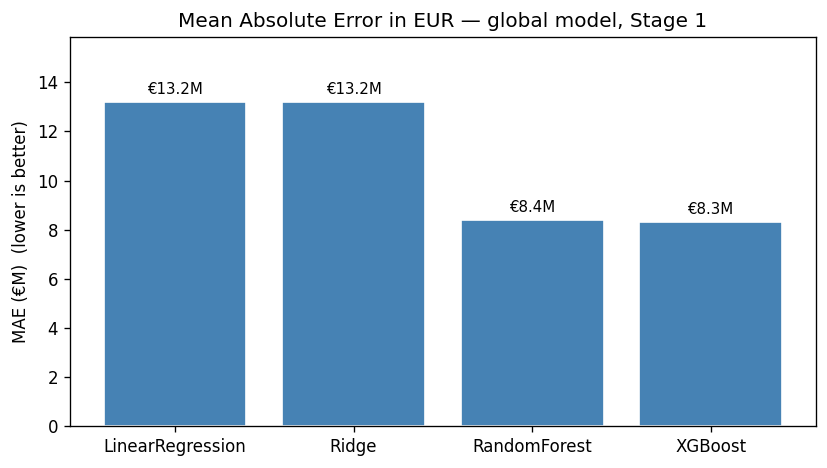

In [15]:
g_s1 = table[(table['position'] == 'global') & (table['stage'] == 'stage1')].copy()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(g_s1['model'], g_s1['MAE_eur_M'], color='steelblue', edgecolor='white')
ax.bar_label(bars, fmt='€%.1fM', padding=3, fontsize=9)
ax.set_ylabel('MAE (€M)  (lower is better)')
ax.set_title('Mean Absolute Error in EUR — global model, Stage 1')
ax.set_ylim(0, max(g_s1['MAE_eur_M']) * 1.2)
plt.tight_layout()
plt.show()

### 5d. Full results table

Complete model × stage × position results. Use this as the basis for the main results table in the report.

**Key columns:**
- `n` — number of player-seasons evaluated (test set size with temporal split, full CV set with single season)
- `R²` — headline metric, log-space
- `Spearman_ρ` — rank correlation — useful when absolute predictions are noisy but ordering is correct
- `MAE_eur_M` — mean absolute error in millions of euros

In [16]:
# Filter to tree models only (linear models noted separately in report)
tree_results = table[table['model'].isin(['RandomForest', 'XGBoost'])]
tree_results.sort_values(['stage', 'position', 'model']).reset_index(drop=True)

,stage,position,model,n,R²,RMSE_log,MAE_log,Spearman_ρ,MAE_eur_M
0,stage1,DEF,RandomForest,224,0.514,0.935,0.684,0.796,7.5
1,stage1,DEF,XGBoost,224,0.496,0.951,0.700,0.789,7.7
2,stage1,FWD,RandomForest,149,0.531,0.906,0.656,0.805,9.4
3,stage1,FWD,XGBoost,149,0.436,0.994,0.726,0.761,10.3
4,stage1,MID,RandomForest,188,0.382,1.084,0.734,0.762,8.5
5,stage1,MID,XGBoost,188,0.350,1.112,0.744,0.766,8.7
6,stage1,global,RandomForest,561,0.493,0.964,0.684,0.807,8.4
7,stage1,global,XGBoost,561,0.497,0.960,0.677,0.805,8.3
8,stage2,DEF,RandomForest,224,0.515,0.933,0.669,0.804,7.3
9,stage2,DEF,XGBoost,224,0.526,0.922,0.660,0.811,7.1


---
## 6. Player lookup — predicted vs actual value

Train the best model (Random Forest, Stage 1) on the full dataset and inspect predictions for individual players. Useful for sanity-checking and for the "where does the model deviate from Transfermarkt?" analysis in the report.

In [17]:
from sklearn.ensemble import RandomForestRegressor
from src.models import _DROP_COLS
from src.features import _aggregate_multi_club, _add_age, _normalize_position

# Train RF on the full Stage 1 dataset
feature_cols = [c for c in s1.columns if c not in _DROP_COLS]
X = s1[feature_cols].fillna(0).values
y = s1['log_market_value'].values

rf = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=3,
                           random_state=42, n_jobs=-1)
rf.fit(X, y)

# Build predictions on Stage 1 rows
pred_df = s1.copy()
pred_df['predicted_log'] = rf.predict(pred_df[feature_cols].fillna(0).values)
pred_df['predicted_eur'] = pred_df['predicted_log'].apply(lambda x: round(np.expm1(x) / 1e6, 1))
pred_df['actual_eur']    = (pred_df['market_value_in_eur'] / 1e6).round(1)
pred_df['error_eur']     = (pred_df['predicted_eur'] - pred_df['actual_eur']).round(1)

# Attach names directly from joined (one row per player-season after dedup)
names = (
    joined[['api_player_id', 'season', 'firstname', 'lastname']]
    .drop_duplicates(['api_player_id', 'season'])
)
lookup = pred_df.merge(names, on=['api_player_id', 'season'], how='left')
lookup['name'] = lookup['firstname'].fillna('') + ' ' + lookup['lastname'].fillna('')

print(f"Predictions ready for {len(lookup)} players.")
print("Sample names:", lookup['name'].dropna().head(5).tolist())

Predictions ready for 1691 players.
Sample names: ['Manuel Obafemi Akanji', 'Manuel Obafemi Akanji', 'Manuel Obafemi Akanji', 'Mahmoud Dahoud', 'Christian Mate Pulišić']


In [18]:
# --- Change the name below to look up any player ---
SEARCH = "Salah"

cols = ['name', 'season', 'age', 'minutes', 'goals', 'assists',
        'actual_eur', 'predicted_eur', 'error_eur']

result = lookup[lookup['name'].str.contains(SEARCH, case=False, na=False)][cols]
result = result.rename(columns={
    'actual_eur': 'actual (€M)',
    'predicted_eur': 'predicted (€M)',
    'error_eur': 'error (€M)',
})
result

,name,season,age,minutes,goals,assists,actual (€M),predicted (€M),error (€M)
111,Mohamed Salah Hamed Mahrous Ghaly,2022,31.0,4519.0,32.0,15.0,65.0,50.0,-15.0
112,Mohamed Salah Hamed Mahrous Ghaly,2023,32.0,3402.0,27.0,13.0,55.0,39.0,-16.0
113,Mohamed Salah Hamed Mahrous Ghaly,2024,33.0,4946.0,36.0,25.0,50.0,37.3,-12.7
1437,Salah Oulad M'Hand,2024,21.9,0.0,0.0,NaN,0.8,1.6,0.8


---
## 7. Projected values for the 2025/26 transfer window

We train on seasons 2022/23–2023/24 and apply the model to **2024/25 stats** (the most recent completed season in our dataset). Players where the model predicts more than Transfermarkt currently shows are potentially undervalued entering the 2025/26 window — their recent output justifies a higher price tag than the market has assigned.

In [19]:
from sklearn.ensemble import RandomForestRegressor
from src.models import _DROP_COLS
from src.features import build_stage1

# Build features for all seasons
s1_all = build_stage1(joined)
feature_cols = [c for c in s1_all.columns if c not in _DROP_COLS]

# Train on 2022/23 + 2023/24, predict on 2024/25 (the most recent completed season)
train = s1_all[s1_all['season'] < 2024]
test  = s1_all[s1_all['season'] == 2024]

rf_prod = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=3,
                                random_state=42, n_jobs=-1)
rf_prod.fit(train[feature_cols].fillna(0).values, train['log_market_value'].values)

# Predict on 2024/25 stats
test = test.copy()
test['predicted_log'] = rf_prod.predict(test[feature_cols].fillna(0).values)
test['predicted_eur'] = test['predicted_log'].apply(lambda x: round(np.expm1(x) / 1e6, 1))
test['actual_eur']    = (test['market_value_in_eur'] / 1e6).round(1)
test['gap_eur']       = (test['predicted_eur'] - test['actual_eur']).round(1)

# Attach player names
names = joined[['api_player_id','season','firstname','lastname']].drop_duplicates(['api_player_id','season'])
test = test.merge(names, on=['api_player_id','season'], how='left')
test['name'] = test['firstname'].fillna('') + ' ' + test['lastname'].fillna('')

print(f"Train: {len(train)} player-seasons (2022/23–2023/24)  |  Test (2024/25): {len(test)} player-seasons")

# Undervalued: model > TM
undervalued = (
    test[test['gap_eur'] > 0]
    .sort_values('gap_eur', ascending=False)
    [['name', 'age', 'minutes', 'goals', 'assists',
      'actual_eur', 'predicted_eur', 'gap_eur']]
    .rename(columns={
        'actual_eur': 'TM value (€M)',
        'predicted_eur': 'model value (€M)',
        'gap_eur': 'undervalued by (€M)',
    })
    .reset_index(drop=True)
)

print(f"Undervalued players: {len(undervalued)} out of {len(test)}")
undervalued.head(25)

INFO Stage 1: 1691 player-seasons, 10 features


Train: 1130 player-seasons (2022/23–2023/24)  |  Test (2024/25): 561 player-seasons
Undervalued players: 222 out of 561


,name,age,minutes,goals,assists,TM value (€M),model value (€M),undervalued by (€M)
0,Dango Aboubacar Faissal Ouattara,23.4,4242.0,16.0,8.0,28.0,62.0,34.0
1,João Pedro Junqueira de Jesus,23.8,4091.0,20.0,13.0,50.0,83.5,33.5
2,Tyrick Kwon Mitchell,25.8,4217.0,1.0,6.0,25.0,53.7,28.7
3,Brennan Price Johnson,24.1,3315.0,18.0,4.0,40.0,66.3,26.3
4,José Diogo Dalot Teixeira,26.3,4363.0,3.0,5.0,30.0,53.5,23.5
5,Mateus Gonçalo Espanha Fernandes,21.0,3364.0,3.0,6.0,15.0,38.2,23.2
6,Jacob Matthew Ramsey,24.1,4161.0,7.0,8.0,32.0,54.1,22.1
7,Oliver George Arthur Watkins,29.5,3578.0,17.0,14.0,40.0,59.2,19.2
8,Pedro Antonio Porro Sauceda,25.8,4130.0,4.0,9.0,38.0,56.3,18.3
9,Maxence Guy Lacroix,25.2,4198.0,1.0,2.0,25.0,42.4,17.4


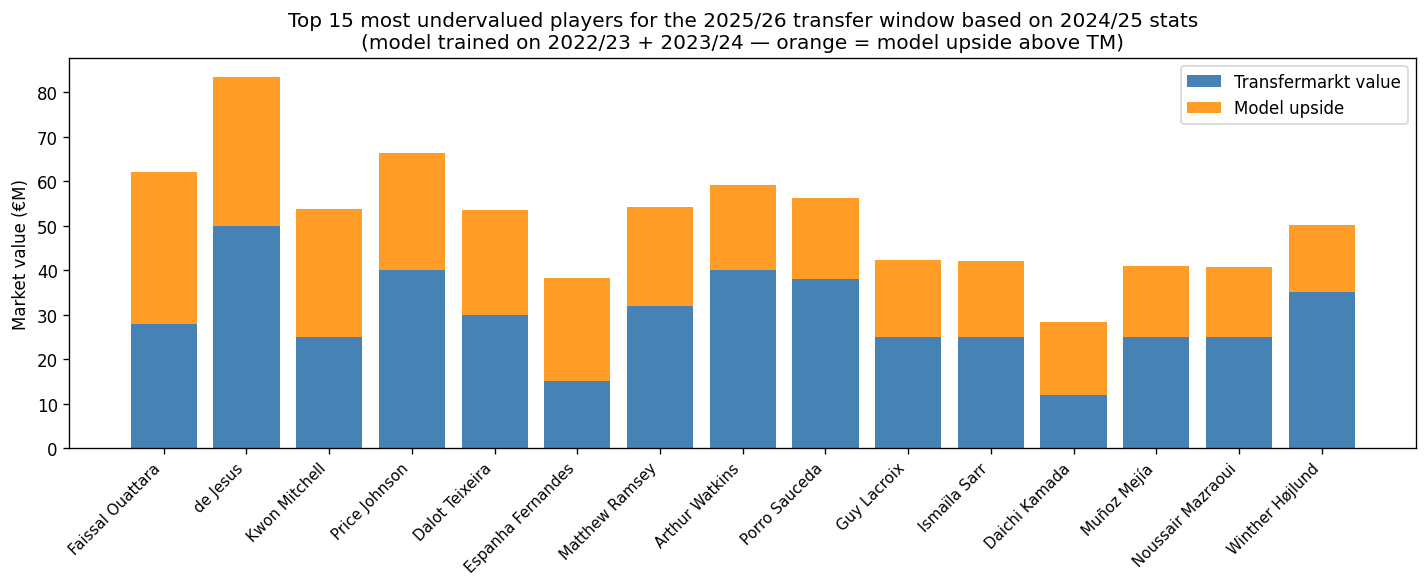

In [20]:
top15 = undervalued.head(15)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(top15))
ax.bar(x, top15['TM value (€M)'], label='Transfermarkt value', color='steelblue')
ax.bar(x, top15['undervalued by (€M)'], bottom=top15['TM value (€M)'],
       label='Model upside', color='darkorange', alpha=0.85)

ax.set_xticks(list(x))
ax.set_xticklabels(
    [' '.join(n.split()[-2:]) for n in top15['name']],
    rotation=45, ha='right', fontsize=9
)
ax.set_ylabel('Market value (€M)')
ax.set_title('Top 15 most undervalued players for the 2025/26 transfer window based on 2024/25 stats\n'
             '(model trained on 2022/23 + 2023/24 — orange = model upside above TM)')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. SHAP feature importance

SHAP (SHapley Additive exPlanations) assigns each feature a contribution score for each individual prediction, then averages across all players. Unlike standard feature importance (which just counts how often a feature is used in splits), SHAP measures the actual *impact on the predicted value*.

We compute SHAP on the 2024/25 test set using the RF model trained on 2022/23 + 2023/24. One plot per position group shows which stats drive value most for each type of player.

**What to look for:**
- **Forwards**: goals and minutes should dominate — goals are the most visible contribution
- **Midfielders**: assists, passes, minutes — creativity and availability
- **Defenders**: minutes and appearances dominate — defensive stats (tackles, interceptions) are harder to translate to value

In [21]:
from src.evaluate import shap_importance

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, position in zip(axes, ['DEF', 'MID', 'FWD']):
    _, shap_vals, feat_names = shap_importance(s1, position=position)
    plt.close('all')  # close figures created inside shap_importance

    mean_abs = np.abs(shap_vals).mean(axis=0)
    top_idx = np.argsort(mean_abs)[::-1][:12]
    top_features = [feat_names[i] for i in top_idx]
    top_vals = mean_abs[top_idx]

    ax.barh(top_features[::-1], top_vals[::-1], color='steelblue')
    ax.set_xlabel('Mean |SHAP value|')
    ax.set_title(f'SHAP importance — {position}')

plt.suptitle('Feature importance by position (RF Stage 1, trained on 2022/23+2023/24, evaluated on 2024/25)',
             fontsize=10, y=1.02)
plt.tight_layout()
plt.show()

INFO SHAP done for position=DEF, test_season=2024, n=224
INFO SHAP done for position=MID, test_season=2024, n=188
INFO SHAP done for position=FWD, test_season=2024, n=149


<Figure size 1200x600 with 0 Axes>

---
## 9. Transfer fee benchmarking

The ultimate test: can the model predict actual transfer fees better than Transfermarkt?

For every PL transfer with a paid fee, we compare:
- **Model error** — `|model prediction − actual fee|`
- **TM error** — `|Transfermarkt value − actual fee|`

If the model's MAE is lower than TM's MAE, that's a meaningful result — it means performance stats alone can price players more accurately than the crowd-sourced consensus.

Note: transfer fees reflect many factors beyond performance (contract length, sell-on clauses, negotiation, hype) — so we expect both errors to be substantial. The question is *which is closer*.

INFO Transfer window 2025/26: 249 paid transfers, checking against 561 predicted players
INFO Benchmark: 90 matched transfers | MAE model=€12.9M | MAE TM=€7.6M | winner=Transfermarkt


Matched transfers: 90
MAE — Model: €12.9M   TM: €7.6M   Winner: Transfermarkt


,player_name,from_club_name,to_club_name,actual_fee_M,tm_value_M,model_value_M,error_model_M,error_tm_M
0,Alexander Isak,Newcastle,Liverpool,145.00,120.0,45.8,99.20,25.00
1,Bryan Mbeumo,Brentford,Man Utd,75.00,55.0,43.7,31.30,20.00
2,Matheus Cunha,Wolves,Man Utd,74.20,60.0,64.7,9.50,14.20
3,Antoine Semenyo,Bournemouth,Man City,72.00,65.0,43.3,28.70,7.00
4,Eberechi Eze,Crystal Palace,Arsenal,69.30,55.0,37.0,32.30,14.30
...,...,...,...,...,...,...,...,...
85,Andrew Irving,West Ham,Sparta Prague,1.50,5.0,5.2,3.70,3.50
86,Chris Mepham,Bournemouth,West Brom,1.15,6.0,4.7,3.55,4.85
87,Malcolm Ebiowei,Crystal Palace,Blackpool,1.15,1.2,1.6,0.45,0.05
88,Emerson,West Ham,Marseille,0.70,10.0,9.5,8.80,9.30


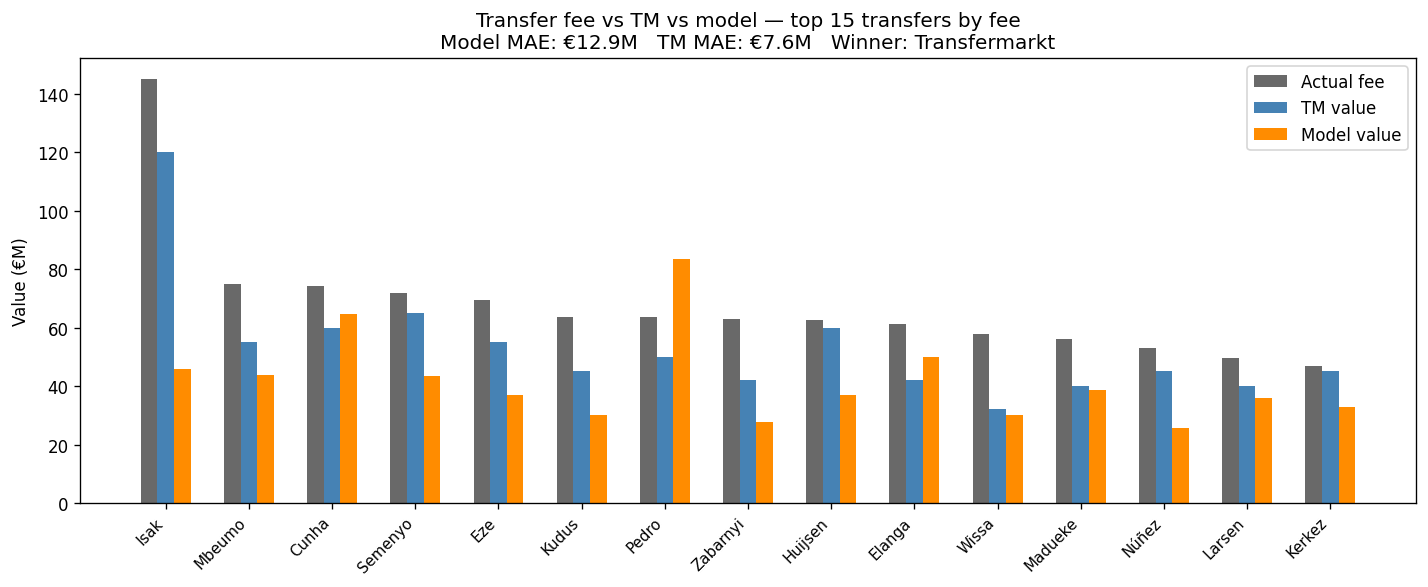

In [22]:
from src.evaluate import build_transfer_benchmark

# Reuse 2024/25 predictions from section 7
# predicted_eur in section 7 is stored in millions — convert back to raw euros for the benchmark
predictions_for_benchmark = test[['tm_player_id', 'predicted_eur', 'market_value_in_eur']].copy()
predictions_for_benchmark['predicted_eur'] = predictions_for_benchmark['predicted_eur'] * 1e6
predictions_for_benchmark = predictions_for_benchmark[predictions_for_benchmark['tm_player_id'].notna()]

benchmark = build_transfer_benchmark(tm.transfers, predictions_for_benchmark)

if benchmark.empty:
    print("No matched transfers found — the transfers dataset may not overlap with predicted players.")
else:
    mae_model = benchmark['error_model_M'].mean()
    mae_tm    = benchmark['error_tm_M'].mean()
    winner = 'MODEL' if mae_model < mae_tm else 'Transfermarkt'
    print(f"Matched transfers: {len(benchmark)}")
    print(f"MAE — Model: €{mae_model:.1f}M   TM: €{mae_tm:.1f}M   Winner: {winner}")
    display(benchmark)

    top_b = benchmark.head(15)
    x = range(len(top_b))

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar([i - 0.2 for i in x], top_b['actual_fee_M'],  width=0.2, label='Actual fee',   color='dimgray')
    ax.bar([i + 0.0 for i in x], top_b['tm_value_M'],    width=0.2, label='TM value',     color='steelblue')
    ax.bar([i + 0.2 for i in x], top_b['model_value_M'], width=0.2, label='Model value',  color='darkorange')

    ax.set_xticks(list(x))
    ax.set_xticklabels(
        [r['player_name'].split()[-1] for _, r in top_b.iterrows()],
        rotation=45, ha='right', fontsize=9
    )
    ax.set_ylabel('Value (€M)')
    ax.set_title(f'Transfer fee vs TM vs model — top {len(top_b)} transfers by fee\n'
                 f'Model MAE: €{mae_model:.1f}M   TM MAE: €{mae_tm:.1f}M   Winner: {winner}')
    ax.legend()
    plt.tight_layout()
    plt.show()